# Spatial clustering with STAGATE + pymclustR

STAGATE is a graph-attention auto-encoder. Bonus: it also produces a denoised expression matrix for downstream marker analysis.

This notebook runs the STAGATE spatial embedder on the
**Maynard 151676 dorsolateral prefrontal cortex** Visium sample
(3 460 spots × 10 747 genes) and clusters the resulting embedding with
[`pymclustR`](https://pypi.org/project/pymclustR/), a pure-Python
re-implementation of CRAN `mclust` (no `rpy2` / R dependency).

> Pre-processed input lives at
> `/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/cluster_svg.h5ad`,
> which is the canonical fixture used in the original `t_cluster_space`
> tutorial.


## 0. Load AnnData + Ground Truth

In [1]:
import omicverse as ov
import scanpy as sc
import pandas as pd, os, anndata as ad

ov.style(font_path='Arial')

# Load the pre-processed AnnData (3460 spots × 10747 genes — the same
# input the original spatial-clustering tutorial was developed against).
DATA_DIR = '/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/data/151676'
H5AD     = '/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/cluster_svg.h5ad'
adata = ad.read_h5ad(H5AD)
truth = pd.read_csv(os.path.join(DATA_DIR, '151676_truth.txt'),
                    sep='\t', header=None, index_col=0)
truth.columns = ['Ground Truth']
adata.obs['Ground Truth'] = truth['Ground Truth'].reindex(adata.obs_names)
print('shape:', adata.shape, '  annotated:',
      adata.obs['Ground Truth'].notna().sum())
adata


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



shape: (3460, 10747)   annotated: 3431


AnnData object with n_obs × n_vars = 3460 × 10747
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'space_variable_features', 'highly_variable'
    uns: 'REFERENCE_MANU', 'spatial'
    obsm: 'spatial'
    layers: 'counts'

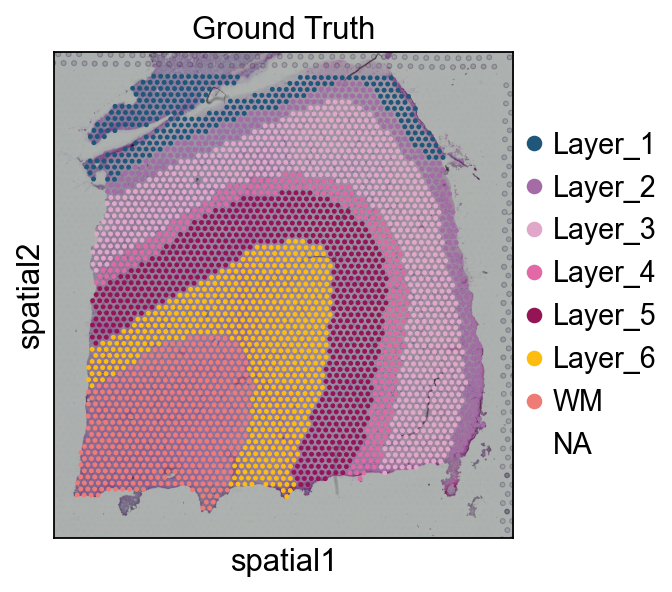

In [2]:
sc.pl.spatial(adata, img_key='hires', color=['Ground Truth'])

## 1. Embed with STAGATE

STAGATE (Dong & Zhang, *Nat. Comm.* 2022) is a graph-attention
auto-encoder that combines spatial neighbourhood structure with gene
expression. Adaptive edge weights let it capture local heterogeneity
even at tissue boundaries.


The STAGATE method is used to cluster the spatial data.


------Calculating spatial graph...
The graph contains 3060 edges, 559 cells.
5.4741 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 3328 edges, 595 cells.
5.5933 neighbors per cell on average.
------Calculating spatial graph...


The graph contains 3448 edges, 613 cells.
5.6248 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 3044 edges, 541 cells.
5.6266 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 3128 edges, 559 cells.
5.5957 neighbors per cell on average.


------Calculating spatial graph...
The graph contains 3320 edges, 595 cells.
5.5798 neighbors per cell on average.


------Calculating spatial graph...


...

 98%|████████████████████████████████████████████████████████████████████████████████████████████████  | 980/1000 [00:15<00:00, 64.64it/s]

 99%|████████████████████████████████████████████████████████████████████████████████████████████████▋ | 987/1000 [00:15<00:00, 64.57it/s]

 99%|█████████████████████████████████████████████████████████████████████████████████████████████████▍| 994/1000 [00:15<00:00, 64.59it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 63.20it/s]

The STAGATE representation values are stored in adata.obsm["STAGATE"].
The rex values are stored in adata.layers["STAGATE_ReX"].
The STAGATE embedding are stored in adata.obsm["STAGATE"].
Shape: (3460, 30)


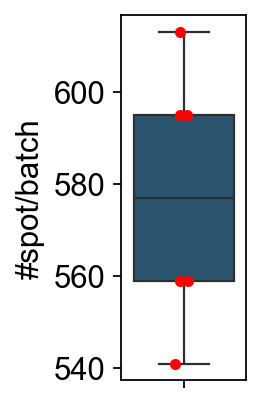

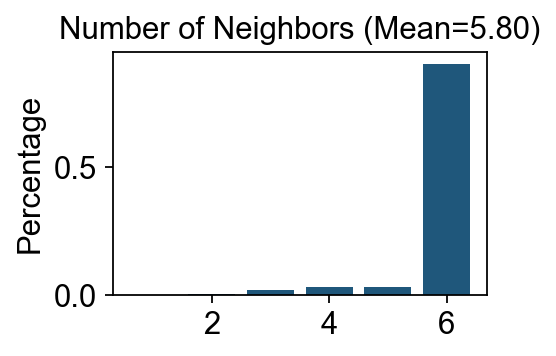

In [3]:
methods_kwargs = {'STAGATE': {
    'num_batch_x': 3, 'num_batch_y': 2,
    'spatial_key': ['X', 'Y'], 'rad_cutoff': 200,
    'num_epoch': 1000, 'lr': 0.001,
    'weight_decay': 1e-4, 'hidden_dims': [512, 30],
    'device': 'cuda:0',
}}
adata = ov.space.clusters(adata, methods=['STAGATE'],
                          methods_kwargs=methods_kwargs)


## 2. Cluster with pymclustR (no rpy2 / R needed)


finished: found 10 clusters and added
    'pymclustR', the cluster labels (adata.obs, categorical)
    [model=EEE, loglik=-215474.7011, BIC=-437256.7467]


  0%|                                                                                                            | 0/3460 [00:00<?, ?it/s]

 38%|███████████████████████████████████▌                                                          | 1307/3460 [00:00<00:00, 13064.06it/s]

 76%|███████████████████████████████████████████████████████████████████████                       | 2614/3460 [00:00<00:00, 13038.07it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 3460/3460 [00:00<00:00, 13020.03it/s]

The merged cluster information is stored in adata.obs["pymclustR_STAGATE_tree"].


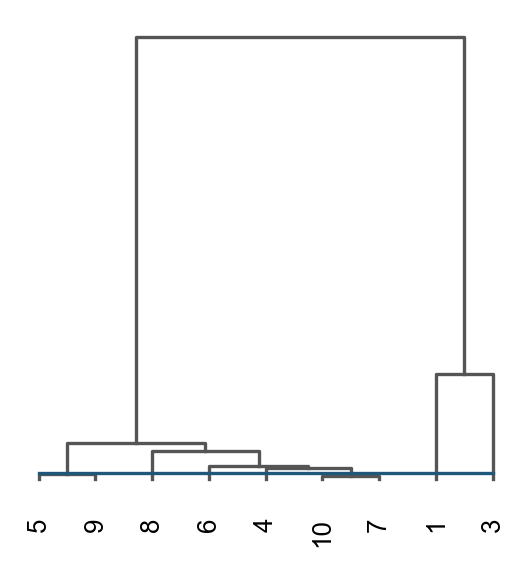

In [4]:
ov.utils.cluster(adata, use_rep='STAGATE', method='pymclustR',
                 n_components=10, modelNames='EEE', random_state=112)
adata.obs['pymclustR_STAGATE'] = ov.utils.refine_label(adata, radius=30, key='pymclustR')
adata.obs['pymclustR_STAGATE'] = adata.obs['pymclustR_STAGATE'].astype('category')
res = ov.space.merge_cluster(adata, groupby='pymclustR_STAGATE',
                             use_rep='STAGATE',
                             threshold=0.005, plot=True)


## 3. Spatial visualisation

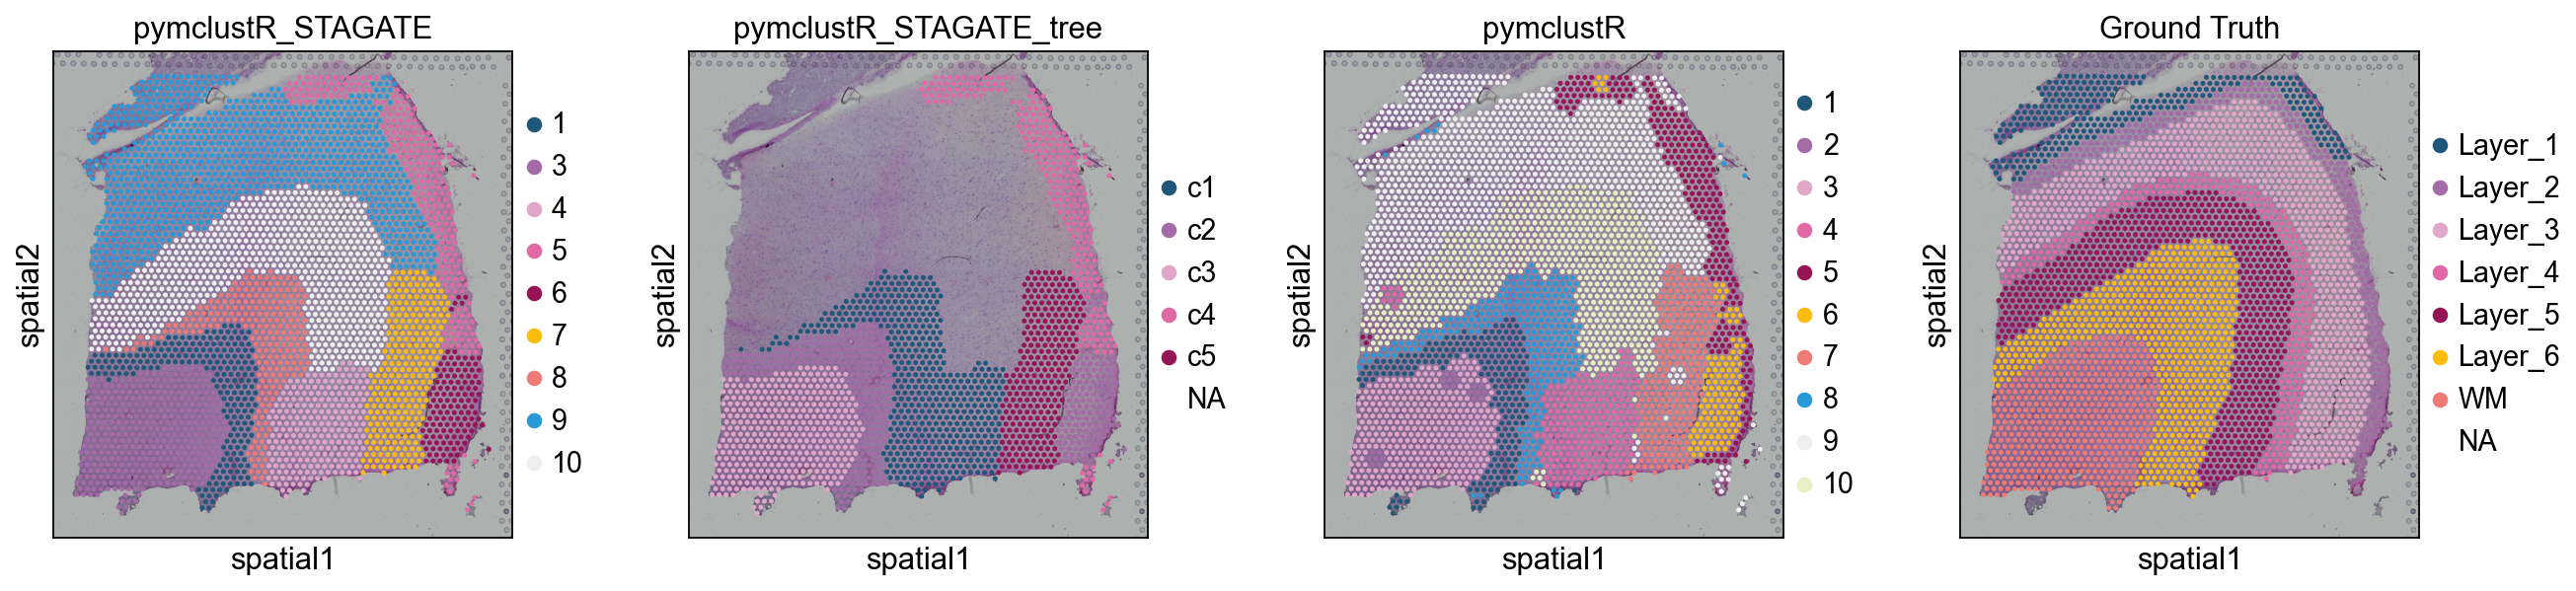

In [5]:
sc.pl.spatial(adata, color=['pymclustR_STAGATE',
                            'pymclustR_STAGATE_tree' if 'pymclustR_STAGATE_tree' in adata.obs.columns else 'pymclustR_STAGATE',
                            'pymclustR', 'Ground Truth'])


## 4. STAGATE denoising — reconstructed expression

STAGATE also produces a denoised reconstruction in
``adata.layers['STAGATE_ReX']``.


[<Axes: title={'center': 'STAGATE_MBP'}, xlabel='spatial1', ylabel='spatial2'>]

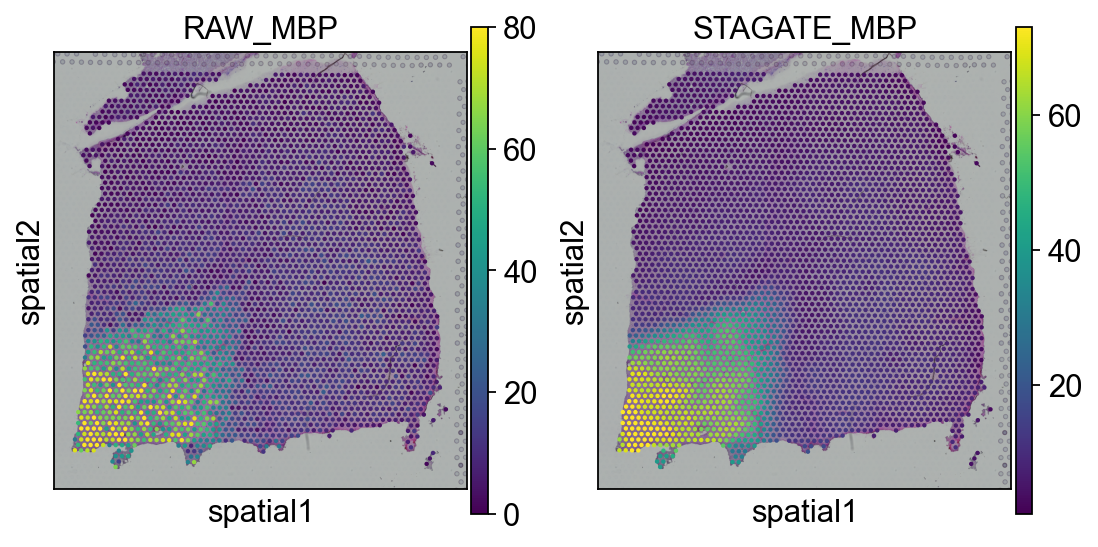

In [6]:
import matplotlib.pyplot as plt
plot_gene = 'MBP'  # myelin marker — sharply enriched in white matter (WM)
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
sc.pl.spatial(adata, img_key='hires', color=plot_gene, show=False,
              ax=axs[0], title='RAW_'+plot_gene, vmax='p99')
sc.pl.spatial(adata, img_key='hires', color=plot_gene, show=False,
              ax=axs[1], title='STAGATE_'+plot_gene, layer='STAGATE_ReX', vmax='p99')


## 5. ARI vs Maynard ground truth

In [7]:
from sklearn.metrics.cluster import adjusted_rand_score

obs = adata.obs.dropna(subset=['Ground Truth'])
ari_raw = adjusted_rand_score(obs['pymclustR'], obs['Ground Truth'])
ari_ref = adjusted_rand_score(obs['pymclustR_STAGATE'], obs['Ground Truth'])
print(f'STAGATE + pymclustR (raw):     ARI = {ari_raw:.4f}')
print(f'STAGATE + pymclustR (refined): ARI = {ari_ref:.4f}')


STAGATE + pymclustR (raw):     ARI = 0.3692
STAGATE + pymclustR (refined): ARI = 0.3756
